In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

In [51]:
N_sin = 4
task, y_bar = sine_square_input_task(Nsegments = 110, wsin= 10.0, Nsin = N_sin, seed = 1234)

array([1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1],
      dtype=int64)

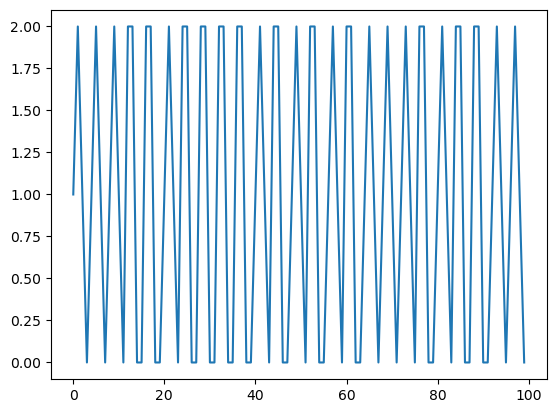

In [53]:
plt.plot(task[:100])
y_bar[::N_sin]

In [59]:
N = 40
A, B = make_esn_weights(
    N,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,)

X = esn_dynamics(task, A, B)
# Generate ESN reservoir states for full time series
X.shape

A norm 5.391668184941067
B norm 3.552413388436475
A/B ratio 1.5177479632555106


(440, 40)

NRMSE: 0.0010057866762634643


Text(0.5, 1.0, 'BTC Prediction by ESN')

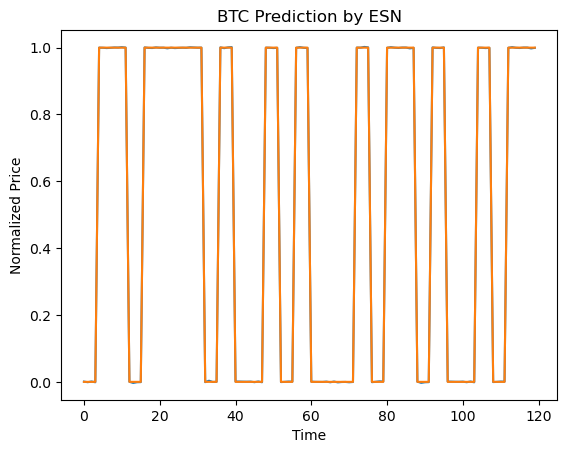

In [61]:
Nfading = 5*N_sin
Ntraining = 75*N_sin 
Ntesting = 110*N_sin-Nfading-Ntraining
X_features = X
X_train = X[Nfading : Nfading + Ntraining, :]
X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = y_bar
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Quantum Performance

In [169]:
N_sin = 8
N = 8
df = pd.read_csv(f"SS{N_sin}sampled_points_rep{N}.csv")
X = extract_block_single_column_pq(df,'PQ-10',N_fts=N,n_samples=110*N_sin, skip_steps=1,mode="both")
X = add_polynomial_features(X,N*2)
X.shape

(880, 80)

In [171]:
task, y_bar = sine_square_input_task(Nsegments = 110, wsin= 10.0, Nsin = N_sin, seed = 1234)

NRMSE: 0.023415384139332127


Text(0.5, 1.0, 'BTC Prediction by ESN')

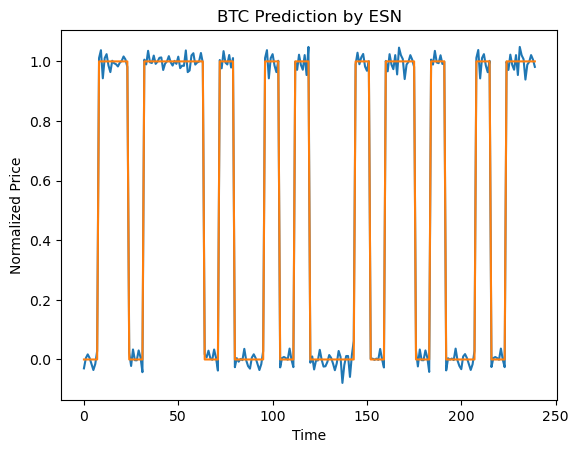

In [173]:
Nfading = 5*N_sin
Ntraining = 75*N_sin 
Ntesting = 110*N_sin-Nfading-Ntraining
X_features = X
X_train = X[Nfading : Nfading + Ntraining, :]
X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = y_bar
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")